# STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [4]:
df = pd.read_csv("RF_WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3: Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 4: Convert TotalCharges to Numeric

=> The Telco dataset stores TotalCharges as Object type.

In [7]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors ='coerce'
)

df['TotalCharges'].dtype

dtype('float64')

# Step 5: Handle Missing Values

In [8]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 6: Drop CustomerID

In [10]:
df.drop('customerID', axis = 1, inplace = True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 7: Target Variable Visualization

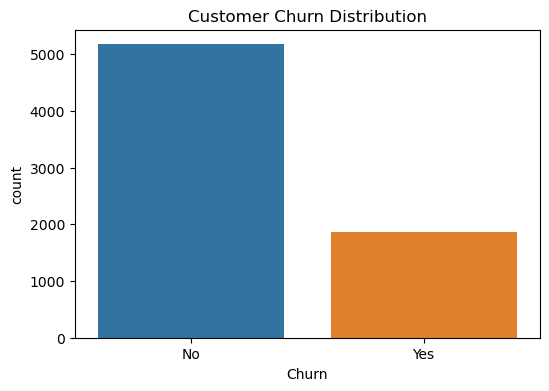

In [11]:
plt.figure(figsize = (6,4))

sns.countplot(
    x = 'Churn',
    data = df
)

plt.title("Customer Churn Distribution")
plt.show()

# Step 8: Encode Categorical Columns

In [14]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Step 9: Correlation Heatmap

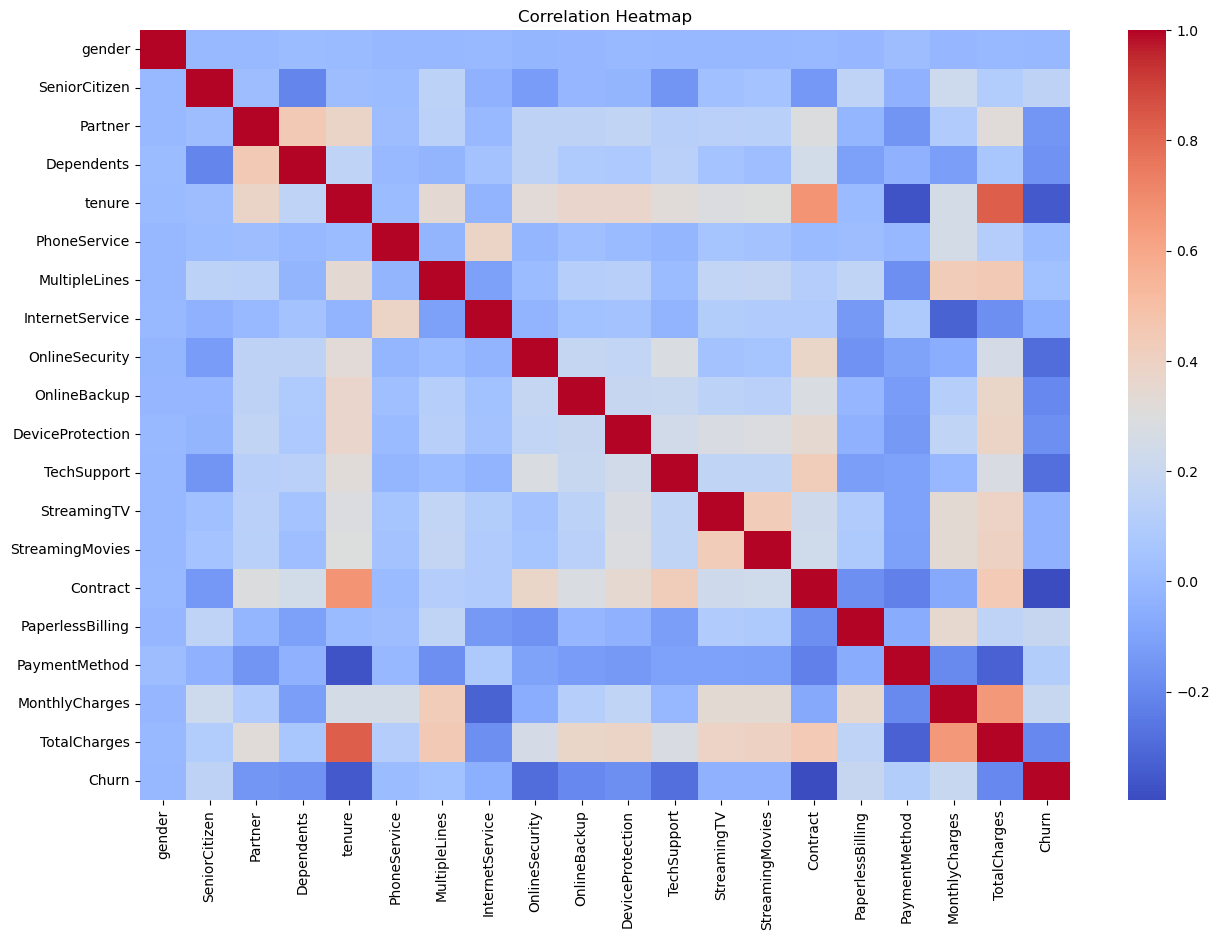

In [15]:
plt.figure(figsize = (15,10))

sns.heatmap(
    df.corr(),
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 10: Define Features and Target

In [16]:
X = df.drop('Churn', axis = 1)

y = df['Churn']

print("X Shape :", X.shape)
print("Y Shape :", y.shape)

X Shape : (7043, 19)
Y Shape : (7043,)


# Step 11: Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


# Step 12: Build Random Forest Model

In [20]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 2,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(
    X_train, 
    y_train
)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

# Step 13: Model Prediction

In [24]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

# Step 14: Accuracy Score

In [26]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 80.27 %


# Step 15: Classification Report

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# Step 16: Confusion Matrix

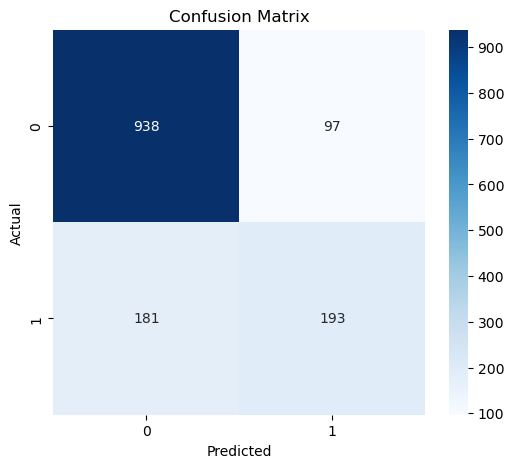

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 17: Feature Importance

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance' : rf_model.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

importance.head(15)

,Feature,Importance
4,tenure,0.162263
18,TotalCharges,0.145594
14,Contract,0.140832
17,MonthlyCharges,0.136970
8,OnlineSecurity,0.078037
11,TechSupport,0.061334
7,InternetService,0.046502
16,PaymentMethod,0.043428
9,OnlineBackup,0.029983
15,PaperlessBilling,0.024862


# Step 18: Feature Importance Graph

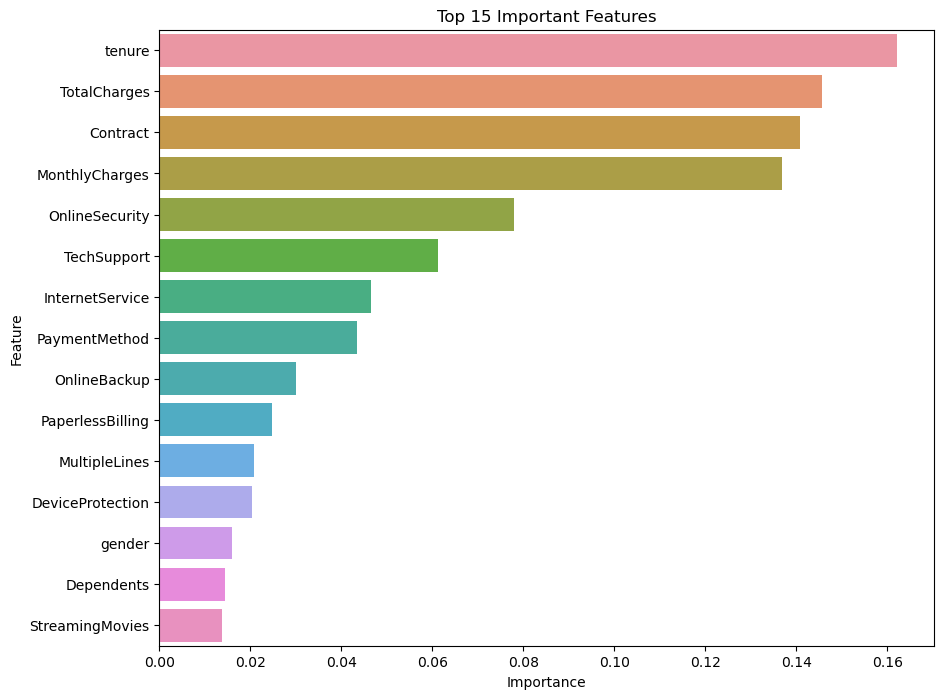

In [34]:
plt.figure(figsize = (10,8))

sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance.head(15)
)

plt.title("Top 15 Important Features")
plt.show()

# Step 19: ROC Curve

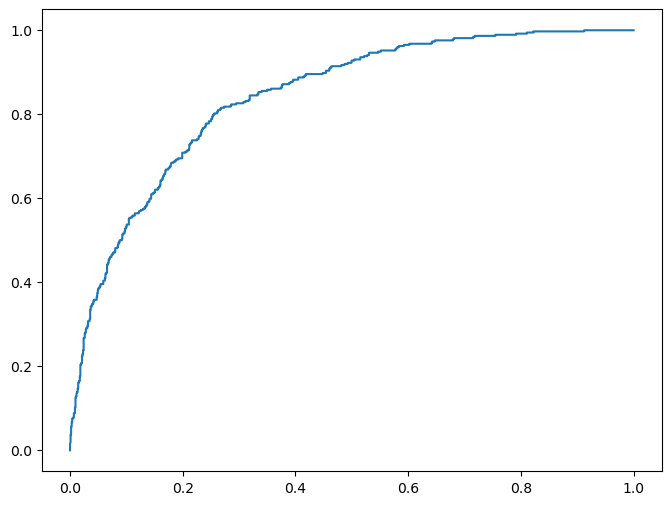

In [36]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.4f}")

# Step 20: Actual vs Predicted

In [38]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0
5748,0,1
3568,0,0
2976,0,0
5928,0,0
1639,1,0


# Step 21: Cross Validation Score

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv = 5
)

print("CV Scores :", scores)
print("Average CV Score :", scores.mean())

CV Scores : [0.80766501 0.80979418 0.78069553 0.80681818 0.8046875 ]
Average CV Score : 0.8019320802955029


# Step 22: Random Forest Tree Visualization

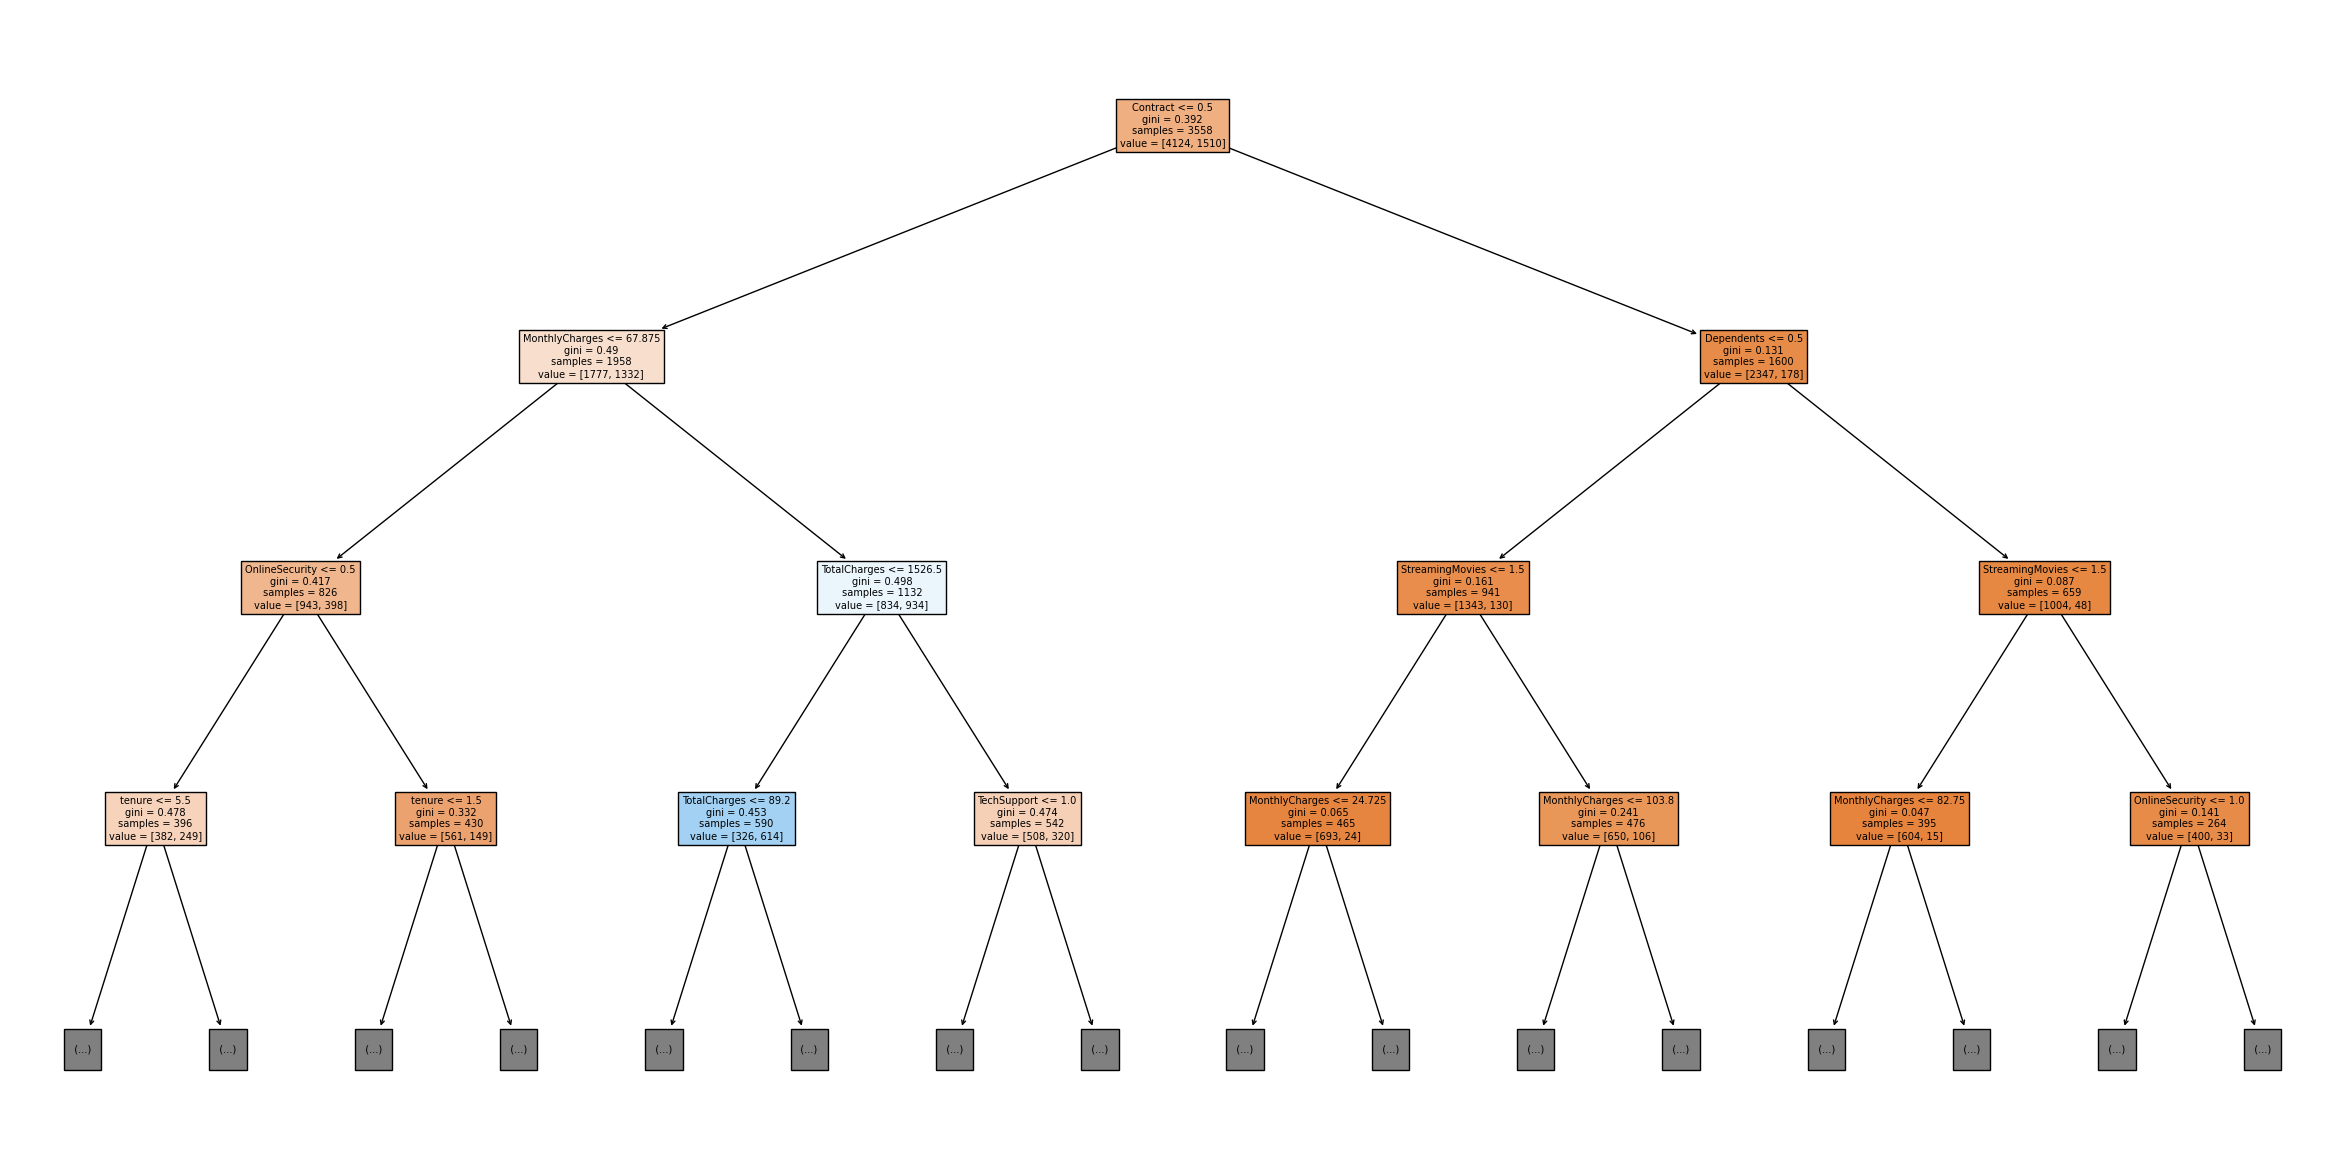

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize = (30,15))

plot_tree(
    rf_model.estimators_[0],
    max_depth = 3,
    filled = True,
    feature_names = X.columns
)

plt.show()

# Final Model Summary

| Metric     | Expected Result                                                                    |
| ---------- | ---------------------------------------------------------------------------------- |
| Algorithm  | Random Forest Classifier                                                           |
| Target     | Churn                                                                              |
| Train/Test | 80/20                                                                              |
| Trees      | 300                                                                                |
| Accuracy   | 78% - 82%                                                                          |
| Evaluation | Accuracy, Precision, Recall, F1                                                    |
| Graphs     | Countplot, Heatmap, Confusion Matrix, Feature Importance, ROC Curve, Decision Tree |


# Random Forest Workflow